**K.V. Kozenko, V.V.Gromyko, I.I. Beterov, I.I.Ryabtsev. Monte-Carlo simulation of performance of amplitude-robust CZ gate at finite temperature of atoms assuming infinite blockade and neglecting spontaneous decay. We simulate trajectories of the atomic motion in the trap. We use Rydopt package David F. Locher, Josias Old, Katharina Brechtelsbauer, Jakob Holschbach, Hans Peter Büchler, Sebastian Weber, Markus Müller, Multiqubit Rydberg Gates for Quantum Error Correction, arXiv:2512.00843**

In [1]:
import rydopt as ro
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

C:\Users\Ilya Beterov\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import numpy as np
w0=1e-6 #beam waist in meters
lam=850e-9 #trap wavelength
z0=np.pi*(w0**2)/lam
cl= 299792458 #light velocity m/s
kB=1.380649e-23 #Boltzmann constant
MRb=87*1.660539e-27 #Rb 87 mass  
U0=1e-4 #trap potential
wr=np.sqrt(4*kB*U0/(MRb*w0**2)) #radial trap frequency in kHz
wz=np.sqrt(2*kB*U0/(MRb*z0**2)) #axial trap frequency in kHz

print("Radial frequency, %.5f kHz " % (wr*1e-3/(2*np.pi)))
print("Axial frequency, %.5f kHz " % (wz*1e-3/(2*np.pi)))

Radial frequency, 31.11771 kHz 
Axial frequency, 5.95335 kHz 


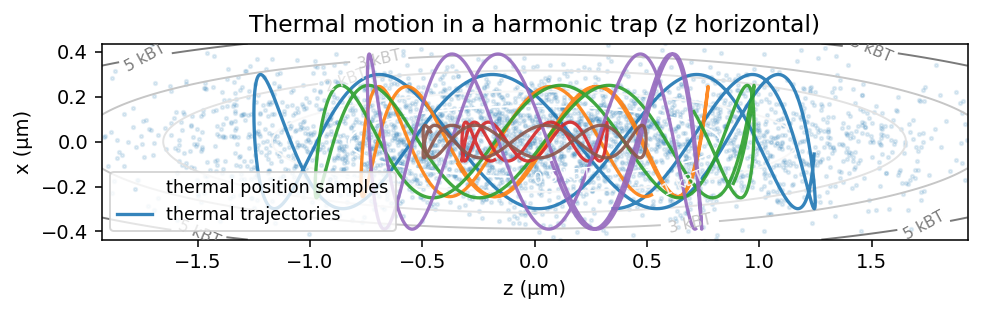

In [3]:
import numpy as np
import matplotlib.pyplot as plt

w0=1e-6 #beam waist in meters
lam=850e-9 #trap wavelength
z0=np.pi*(w0**2)/lam
cl= 299792458 #light velocity m/s
kB=1.380649e-23 #Boltzmann constant
m=87*1.660539e-27 #Rb 87 mass  
U0=1e-4 #trap potential
omega_x=np.sqrt(4*kB*U0/(MRb*w0**2)).item() #radial trap frequency in kHz
omega_z=np.sqrt(2*kB*U0/(MRb*z0**2)).item() #axial trap frequency in kHz



# -----------------------------
# Thermal motion in a harmonic trap (2D: x-z), with z on the HORIZONTAL axis
# and tight axis limits to avoid empty space.
# -----------------------------


# --- User parameters ---

T = 10e-6                 # K
#omega_x = 2*np.pi*28.3e3   # rad/s (tight direction)
#omega_z = 2*np.pi*4.9e3     # rad/s (weak direction)



# Simulation controls
t_end = 0.2e-3
n_t = 3500
seed = 3

# How many thermal trajectories to draw
n_traj = 6

# Thermal scatter cloud (equilibrium spatial distribution)
n_scatter = 3500

# Tight-limits controls
pad_frac = 0.12           # fractional padding around data bounds
percentile_clip = 99.5    # clip extreme scatter outliers for nicer framing

rng = np.random.default_rng(seed)

# -----------------------------
# Thermal widths (classical canonical equilibrium in harmonic trap)
# -----------------------------
sigma_x = np.sqrt(kB*T/(m*omega_x**2))
sigma_z = np.sqrt(kB*T/(m*omega_z**2))
sigma_v = np.sqrt(kB*T/m)

# Scatter samples from P(x,z) (Gaussian)
xs = rng.normal(0.0, sigma_x, size=n_scatter)
zs = rng.normal(0.0, sigma_z, size=n_scatter)

# Time grid
t = np.linspace(0.0, t_end, n_t)

def trajectory(x0, z0, vx0, vz0):
    """Analytic harmonic oscillator trajectory in each axis."""
    x = x0*np.cos(omega_x*t) + (vx0/omega_x)*np.sin(omega_x*t)
    z = z0*np.cos(omega_z*t) + (vz0/omega_z)*np.sin(omega_z*t)
    return x, z

# Generate multiple trajectories with thermal initial conditions
traj_x = []
traj_z = []
for _ in range(n_traj):
    x0 = rng.normal(0.0, sigma_x)
    z0 = rng.normal(0.0, sigma_z)
    vx0 = rng.normal(0.0, sigma_v)
    vz0 = rng.normal(0.0, sigma_v)
    x, z = trajectory(x0, z0, vx0, vz0)
    traj_x.append(x)
    traj_z.append(z)

traj_x = np.array(traj_x)  # shape (n_traj, n_t)
traj_z = np.array(traj_z)

# -----------------------------
# Choose tight plot limits based on scatter + trajectories
# (clip outliers for nicer framing)
# -----------------------------
all_x = np.concatenate([xs, traj_x.ravel()])
all_z = np.concatenate([zs, traj_z.ravel()])

x_lim = np.percentile(np.abs(all_x), percentile_clip)
z_lim = np.percentile(np.abs(all_z), percentile_clip)

x_lim *= (1.0 + pad_frac)
z_lim *= (1.0 + pad_frac)

# -----------------------------
# Background potential contours U(x,z) = 1/2 m (wx^2 x^2 + wz^2 z^2)
# We'll plot U/kBT as a function of (z,x) so that z is horizontal.
# -----------------------------
nx, nz = 240, 260
x_axis = np.linspace(-x_lim, x_lim, nx)
z_axis = np.linspace(-z_lim, z_lim, nz)

ZZ, XX = np.meshgrid(z_axis, x_axis)  # note: horizontal is Z, vertical is X
U_over_kBT = (0.5*m*(omega_x**2 * XX**2 + omega_z**2 * ZZ**2)) / (kB*T)

# -----------------------------
# Plot (z on horizontal axis, x on vertical axis)
# -----------------------------
plt.figure(figsize=(7.2, 5.2), dpi=140)

levels = [0.5, 1, 2, 3, 5, 8]
cs = plt.contour(ZZ*1e6, XX*1e6, U_over_kBT, levels=levels, cmap="Greys", linewidths=1.0)
plt.clabel(cs, fmt=lambda v: f"{v:g} kBT", fontsize=8)

# Scatter cloud (equilibrium position samples)
plt.scatter(zs*1e6, xs*1e6, s=3, alpha=0.12, color="tab:blue", label="thermal position samples")

# Trajectories
for i in range(n_traj):
    plt.plot(traj_z[i]*1e6, traj_x[i]*1e6, lw=1.7, alpha=0.9, label="thermal trajectories" if i == 0 else None)

plt.xlabel("z (µm)")  # horizontal
plt.ylabel("x (µm)")  # vertical
plt.title("Thermal motion in a harmonic trap (z horizontal)")

# Tight limits (avoid empty space)
plt.xlim(-z_lim*1e6, z_lim*1e6)
plt.ylim(-x_lim*1e6, x_lim*1e6)

# Use 'equal' if you want true spatial scaling; 'auto' fills the frame more.
plt.gca().set_aspect("equal", adjustable="box")

plt.legend(frameon=True, fontsize=9)
plt.tight_layout()
plt.savefig('AtomMotion.svg', format='svg')
plt.show()


In [4]:
def Rabi(r: float, z: float, lam: float, w0=1e-6):
    z0=np.pi*w0**2/lam
    return np.exp(-r**2/(w0**2))*np.exp(-z**2/(2*(z0**2)))

**Now we analayze robustness of two-photon scheme to asymmetry**

**Asymmetric two-photon gate with infinite blockade strength**

In [5]:
from rydopt.types import HamiltonianFunction
class CZGateTwoPhotonAsymm:

    def __init__(self, Vnn: float, Delta1P: float,  Delta2P :float,  DecayP=0, DecayR=0, s1=1, s2=1, p1=1, p2=1, f1=1, f2=1):
        self._Delta1P = Delta1P
        self._Delta2P = Delta2P
        self._DecayP = DecayP
        self._DecayR = DecayR
        self._Vnn = Vnn
        self._s1=s1 #relative Rabi frequency OmegaS
        self._s2=s2
        self._p1=p1 #relative Rabi frequency OmegaP
        self._p2=p2
        self._f1=f1 #relative two-photon detuning
        self._f2=f2
        
    def initial_basis_states(self) -> tuple[jnp.ndarray, ...]:
        return jnp.array([1,0,0], dtype=complex), jnp.array([1,0,0], dtype=complex), jnp.array([1,0,0,0,0,0,0,0,0], dtype=complex)

    def hamiltonian_functions_for_basis_states(self) -> tuple[HamiltonianFunction, ...]:
        
        def hamiltonian1(Delta: float, Xi: float, Omega: float) -> jnp.ndarray:
            """single-atom excitation with states 01,0e,0r"""
            s1=self._s1
            p1=self._p1
            f1=self._f1
            Delta1=Delta*f1
            Delta1P=self._Delta1P
            DecayP=self._DecayP
            DecayR=self._DecayR

            
            Omega1S=jnp.sqrt(2*np.abs(Delta1P)*Omega)*jnp.exp(-1j*Xi)*s1
            Omega1SC=jnp.sqrt(2*np.abs(Delta1P)*Omega)*jnp.exp(+1j*Xi)*s1
            
            Omega1P=jnp.sqrt(2*np.abs(Delta1P)*Omega)*p1
            Omega1PC=jnp.sqrt(2*np.abs(Delta1P)*Omega)*p1
            
              
            return jnp.array(
            [
                    [0, 0.5*Omega1P, 0], 
                    [0.5*Omega1PC, -0.5*1j*DecayP - Delta1P, 0.5*Omega1S], 
                    [0, 0.5*Omega1SC, -0.5*1j*DecayR + Delta1]                                    
                ]
            )

        def hamiltonian2(Delta: float, Xi: float, Omega: float) -> jnp.ndarray:
            """single-atom excitation with states 01,0e,0r"""
            s2=self._s2
            p2=self._p2
            f2=self._f2
            Delta2=Delta*f2
            Delta2P=self._Delta2P
            DecayP=self._DecayP
            DecayR=self._DecayR

        
            Omega2S=jnp.sqrt(2*np.abs(Delta2P)*Omega)*jnp.exp(-1j * Xi)*s2
            Omega2SC=jnp.sqrt(2*np.abs(Delta2P)*Omega)*jnp.exp(1j * Xi)*s2
            
            Omega2P=jnp.sqrt(2*np.abs(Delta2P)*Omega)*p2
            Omega2PC=jnp.sqrt(2*np.abs(Delta2P)*Omega)*p2
            return jnp.array(
                [
                    [0, 0.5*Omega2P, 0], 
                    [0.5*Omega2PC, -0.5*1j*DecayP - Delta2P, 0.5*Omega2S], 
                    [0, 0.5*Omega2SC, -0.5*1j*DecayR + Delta2]                                    
                ]                                           
                
            )
        def hamiltonian3(Delta: float, Xi: float, Omega: float) -> jnp.ndarray:
            """two-atom excitation with states 11,1e+e1,1r+r1,ee,er+re,rr"""
            f1=self._f1
            f2=self._f2
            Delta1=Delta*f1
            Delta2=Delta*f2
            Delta1P=self._Delta1P
            Delta2P=self._Delta2P
            DecayP=self._DecayP
            DecayR=self._DecayR
            Vnn=self._Vnn
            s1=self._s1
            p1=self._p1
            s2=self._s2
            p2=self._p2

            
            Omega1S=jnp.sqrt(2*np.abs(Delta1P)*Omega)*jnp.exp(-1j*Xi)*s1
            Omega1SC=jnp.sqrt(2*np.abs(Delta1P)*Omega)*jnp.exp(1j* Xi)*s1
            
            Omega1P=jnp.sqrt(2*np.abs(Delta1P)*Omega)*p1
            Omega1PC=jnp.sqrt(2*np.abs(Delta1P)*Omega)*p1
            
            Omega2S=jnp.sqrt(2*np.abs(Delta2P)*Omega)*jnp.exp(-1j * Xi )*s2
            Omega2SC=jnp.sqrt(2*np.abs(Delta2P)*Omega)*jnp.exp(1j * Xi )*s2
            
            Omega2P=jnp.sqrt(2*np.abs(Delta2P)*Omega)*p2
            Omega2PC=jnp.sqrt(2*np.abs(Delta2P)*Omega)*p2
            
            return jnp.array([
                [0, 0.5*Omega1P, 0, 0.5*Omega2P, 0, 0, 0, 0, 0],
                [0.5*Omega1PC, -0.5*1j*DecayP - 1.0*Delta1P, 0.5*Omega1S, 0, 0.5*Omega2P, 0, 0, 0, 0],
                [0, 0.5*Omega1SC, -0.5*1j*DecayR + Delta1, 0, 0, 0.5*Omega2P, 0, 0, 0],
                [0.5*Omega2PC, 0, 0, -0.5*1j*DecayP - 1.0*Delta2P, 0.5*Omega1P, 0, 0.5*Omega2S, 0, 0],
                [0, 0.5*Omega2PC, 0, 0.5*Omega1PC, -1.0*1j*DecayP - 1.0*Delta1P - 1.0*Delta2P, 0.5*Omega1S, 0, 0.5*Omega2S, 0],
                [0, 0, 0.5*Omega2PC, 0, 0.5*Omega1SC, -0.5*1j*DecayP - 0.5*1j*DecayR + 1.0*Delta1 - 1.0*Delta2P, 0, 0, 0.5*Omega2S],
                [0, 0, 0, 0.5*Omega2SC, 0, 0, -0.5*1j*DecayR + 1.0*Delta2, 0.5*Omega1P, 0],
                [0, 0, 0, 0, 0.5*Omega2SC, 0, 0.5*Omega1PC, -0.5*1j*DecayP - 0.5*1j*DecayR - 1.0*Delta1P + 1.0*Delta2, 0.5*Omega1S],
                [0, 0, 0, 0, 0, 0.5*Omega2SC, 0, 0.5*Omega1SC, -1.0*1j*DecayR + 1.0*Delta1 + 1.0*Delta2+Vnn]       
            ]

              
            )
        return hamiltonian1, hamiltonian2,hamiltonian3
 
    
    def process_fidelity(
        self, final_basis_states: tuple[jnp.ndarray, ...]
    ) -> jnp.ndarray:
        # Obtained diagonal gate matrix
        obtained_gate = jnp.array(
            [
                1,
                final_basis_states[0][0],
                final_basis_states[1][0],
                final_basis_states[2][0],
            ]
        )

        # Targeted diagonal gate matrix
        p1 = jnp.angle(obtained_gate[1]) 
        p2 = jnp.angle(obtained_gate[2]) 
        t = np.pi
        targeted_gate = jnp.stack(
            [
                1,
                jnp.exp(1j * p1),
                jnp.exp(1j * p2),
                jnp.exp(1j * ( p1+p2 + t)),
            ]
        )
        return jnp.abs(jnp.vdot(targeted_gate, obtained_gate)) ** 2 / len(targeted_gate) ** 2

***Asymmetric smooth robust gate optimized for finite blockade strength BT=300***

In [6]:
pulse_ansatz_to = ro.pulses.PulseAnsatz(detuning_ansatz=ro.pulses.const,
                                        phase_ansatz=ro.pulses.lin_sin_cos_crab,
                                        rabi_ansatz=ro.pulses.softbox_seventh_order_smoothstep)
lifetimep=26e-3
C6=2058e3
Rr =4
Time_Scaling=10
lifetimeRyd=180.43861733582934 #76S lifetime
initial_params= (1.0, [9.115935325622559], [0.39692422747612, 0.7427433729171753, -1.279449701309204, 0.2767230272293091, 1.8114371299743652, 0.1470489799976349, -0.10822805762290955, 0.167483851313591, -0.17052917182445526, -0.15532198548316956, 0.17144492268562317, -0.012233825400471687, -0.5968111157417297, 0.8911120891571045, 0.16720227897167206, -0.3219967186450958, -0.5767694115638733, -0.14029094576835632, 0.539829432964325, -0.21630090475082397, -0.6181842684745789], [22.405344009399414, 0.24402165412902832])
#gate = ro.gates.TwoQubitGate(phi=None, theta=np.pi, Vnn=float("inf"), decay=0.0)
gate = CZGateTwoPhotonAsymm(Vnn=2*np.pi*C6/Rr**6/Time_Scaling,Delta1P=2*np.pi*70000/Time_Scaling,Delta2P=2*np.pi*70000/Time_Scaling,s1=1 ,s2=1.0,p1=1 ,p2=1.0, f1=1.0,f2=1.0,DecayP=1/5/lifetimep,DecayR=1/5/lifetimeRyd)
time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz_to, initial_params)
1-gate.process_fidelity(time_evolved_basis_states).item()

0.0013200329397754507

In [6]:
2*np.pi*C6/Rr**6/10

315.6932461468649

***Time-optimal gate optimized for blockade strength BT=300***

In [7]:
pulse_ansatz_to = ro.pulses.PulseAnsatz(detuning_ansatz=ro.pulses.const,
                                        phase_ansatz=ro.pulses.sin_crab,
                                        rabi_ansatz=ro.pulses.softbox_seventh_order_smoothstep)
lifetimep=26e-3
C6=2058e3
Rr=4
lifetimeRyd=180.43861733582934 #76S lifetime
Time_Scaling=10
initial_params=(1.0, [0.14235801], [1.30169946, 0.66107815], [8.21751909, 0.14535794])
gate = CZGateTwoPhotonAsymm(Vnn=2*np.pi*C6/Rr**6/Time_Scaling,Delta1P=2*np.pi*70000/Time_Scaling,Delta2P=2*np.pi*70000/Time_Scaling,s1=1 ,s2=1.0,p1=1 ,p2=1.0, f1=1.0,f2=1.0,DecayP=1/5/lifetimep,DecayR=1/5/lifetimeRyd)
time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz_to, initial_params)
1-gate.process_fidelity(time_evolved_basis_states).item()

0.0013634640400626008

***testing trajectories***

In [4]:
w0=1e-6 #beam waist in meters
lam=850e-9 #trap wavelength
z0=np.pi*(w0**2)/lam
cl= 299792458 #light velocity m/s
kB=1.380649e-23 #Boltzmann constant
MRb=87*1.660539e-27 #Rb 87 mass  
U0=1e-4 #trap potential
C6=-2058e3 #c6 coefficient for 80s in MHz
wr=np.sqrt(4*kB*U0/(MRb*w0**2)) #radial trap frequency in kHz
wz=np.sqrt(2*kB*U0/(MRb*z0**2)) #axial trap frequency in kHz
pulse_ansatz_to = ro.pulses.PulseAnsatz(detuning_ansatz=ro.pulses.const,
                                        phase_ansatz=ro.pulses.lin_sin_cos_crab,
                                        rabi_ansatz=ro.pulses.softbox_seventh_order_smoothstep)

T=1e-6 #list of temperatures
sigma_xy=np.sqrt(kB*T/(MRb*wr**2))  #x and y spread
sigma_z=np.sqrt(kB*T/(MRb*wz**2)) #z spread
sigma_v=np.sqrt(kB*T/(MRb)) # velocity spread

N=100    
t = rng.uniform(0, 2*np.pi/omega_z, size=(N, 2))  #time points during one cycle of trap motion
    # Initial conditions for two atoms (2) for N shots
x0  = rng.normal(0.0, sigma_xy, size=(N, 2))
y0  = rng.normal(0.0, sigma_xy, size=(N, 2))
z0  = rng.normal(0.0, sigma_z,  size=(N, 2))
vx0 = rng.normal(0.0, sigma_v,  size=(N, 2))
vy0 = rng.normal(0.0, sigma_v,  size=(N, 2))
vz0 = rng.normal(0.0, sigma_v,  size=(N, 2))

    # Harmonic evolution (analytic)
cr, sr = np.cos(wr * t), np.sin(wr * t)
cz, sz = np.cos(wz * t), np.sin(wz * t)

x  = x0 * cr + (vx0 / wr) * sr
y  = y0 * cr + (vy0 / wr) * sr
z  = z0 * cz + (vz0 / wz) * sz
vz = -z0 *wz * sz + vz0 * cz

r = np.sqrt(x*x + y*y)


Radial1 = r[:, 0]
Axial1 = z[:, 0]
Radial2 = r[:, 1]
Axial2 = z[:, 1]
Vz1= vz[:, 0]
Vz2= vz[:, 1]

In [5]:
T=1e-5
np.sqrt(kB*T/(MRb))

np.float64(0.030914161755881304)

In [6]:
np.sqrt(kB*T/(MRb))*1e-7

np.float64(3.0914161755881305e-09)

***Amplitude-robust 480 nm+780 nm 80S state 100 ns gate duration with 50 GHz detuning 4 microns interatomic distance. The gate timing is rescaled by a factor of 10 <span style="color:red">(посчитано)</span>***

In [ ]:
w0=1e-6 #beam waist in meters
lam=850e-9 #trap wavelength
z0=np.pi*(w0**2)/lam
cl= 299792458 #light velocity m/s
kB=1.380649e-23 #Boltzmann constant
MRb=87*1.660539e-27 #Rb 87 mass  
U0=1e-4 #trap potential
C6=-2058e3 #c6 coefficient for 76s in MHz
wr=np.sqrt(4*kB*U0/(MRb*w0**2)) #radial trap frequency in kHz
wz=np.sqrt(2*kB*U0/(MRb*z0**2)) #axial trap frequency in kHz
pulse_ansatz_to = ro.pulses.PulseAnsatz(detuning_ansatz=ro.pulses.const,
                                        phase_ansatz=ro.pulses.lin_sin_cos_crab,
                                        rabi_ansatz=ro.pulses.softbox_seventh_order_smoothstep)
lifetimep=26e-3
lifetimeRyd=180.43861733582934 #76S lifetime
initial_params=(1.0, [9.121445655822754], [0.40243253111839294, 0.7589524984359741, -1.2777073383331299, 0.2604377269744873, 1.7878552675247192, 0.1500038355588913, -0.13677142560482025, 0.14020198583602905, -0.1863752007484436, -0.14489804208278656, 0.1924409419298172, -0.018599489703774452, -0.6102868318557739, 0.8758513927459717, 0.1380738765001297, -0.32945048809051514, -0.5795151591300964, -0.1269419640302658, 0.5316967964172363, -0.2201061248779297, -0.6058393120765686], [22.428089141845703, 0.24895963072776794])
Time_Scaling=5 #Scaling factor used in Rabi frequencies, decay rates and interaction strengths.
Tlist=np.linspace(1e-6,1e-5,6)
rng = np.random.default_rng()

RobustTdep480D=[]
N = 100 #data size

for j in range(len(Tlist)):
    T=Tlist[j] #list of temperatures
    sigma_xy=np.sqrt(kB*T/(MRb*wr**2))  #x and y spread
    sigma_z=np.sqrt(kB*T/(MRb*wz**2)) #z spread
    sigma_v=np.sqrt(kB*T/(MRb)) # velocity spread
    
    
    t = rng.uniform(0, 2*np.pi/omega_z, size=(N, 2))  #time points during one cycle of trap motion
    # Initial conditions for two atoms (2) for N shots
    x0  = rng.normal(0.0, sigma_xy, size=(N, 2))
    y0  = rng.normal(0.0, sigma_xy, size=(N, 2))
    z0  = rng.normal(0.0, sigma_z,  size=(N, 2))
    vx0 = rng.normal(0.0, sigma_v,  size=(N, 2))
    vy0 = rng.normal(0.0, sigma_v,  size=(N, 2))
    vz0 = rng.normal(0.0, sigma_v,  size=(N, 2))

    # Harmonic evolution (analytic)
    cr, sr = np.cos(wr * t), np.sin(wr * t)
    cz, sz = np.cos(wz * t), np.sin(wz * t)

    x  = x0 * cr + (vx0 / wr) * sr
    y  = y0 * cr + (vy0 / wr) * sr
    z  = z0 * cz + (vz0 / wz) * sz
    vz = -z0 *wz * sz + vz0 * cz
    R=np.sqrt((x[:,0]-x[:,1]+4.1e-6)**2+(y[:,0]-y[:,1])**2+(z[:,0]-z[:,1])**2)*1e6
    Varr=-2*np.pi*C6/R**6
    r = np.sqrt(x*x + y*y)
    
    Radial1 = r[:, 0]
    Axial1 = z[:, 0]
    Radial2 = r[:, 1]
    Axial2 = z[:, 1]
    Vz1= vz[:, 0]
    Vz2= vz[:, 1]
    Doppler1=Vz1*1e-6*2*np.pi*(1/(480e-9)-1/(780e-9))/Time_Scaling 
    Doppler2=Vz2*1e-6*2*np.pi*(1/(480e-9)-1/(780e-9))/Time_Scaling
    
    ScalingP1=Rabi(Radial1,Axial1,780e-9)
    ScalingS1=Rabi(Radial1,Axial1,480e-9)
    ScalingP2=Rabi(Radial2,Axial2,780e-9)
    ScalingS2=Rabi(Radial2,Axial2,480e-9)

    Detuning1=(initial_params[1]+Doppler1)/initial_params[1]
    Detuning2=(initial_params[1]+Doppler2)/initial_params[1]
    FRobustT=[]
    print("j= %.i " % j)
    for i in range(len(ScalingP1)):
        gate = CZGateTwoPhotonAsymm(Vnn=Varr[i]/Time_Scaling,Delta1P=2*np.pi*70000/Time_Scaling,Delta2P=2*np.pi*70000/Time_Scaling,DecayP=1/Time_Scaling/lifetimep,DecayR=1/Time_Scaling/lifetimeRyd,s1=ScalingS1[i] ,s2=ScalingS2[i],p1=ScalingP1[i] ,p2=ScalingP2[i],f1= Detuning1[i],f2= Detuning2[i])
        pulse_params  = initial_params[0],initial_params[1],initial_params[2],initial_params[3],
        time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz_to, pulse_params)
        errF=1-gate.process_fidelity(time_evolved_basis_states).item()
        FRobustT.append(errF)
        print(i,errF)
    RobustTdep480D.append(np.mean(FRobustT).item())
RobustTdep480D

In [12]:
RobustTdep480D=[0.0008746996451944278,
 0.0013250631757030474,
 0.002569035137178444,
 0.006075287728171503,
 0.010354291369018992,
 0.014962872075457918]

***Time-optimal 480 nm+780 nm 80S state 100 ns gate duration with 50 GHz detuning 4 microns interatomic distance. The gate timing is rescaled by a factor of 10 <span style="color:red">Посчитано</span>***

In [ ]:
w0=1e-6 #beam waist in meters
lam=850e-9 #trap wavelength
z0=np.pi*(w0**2)/lam
cl= 299792458 #light velocity m/s
kB=1.380649e-23 #Boltzmann constant
MRb=87*1.660539e-27 #Rb 87 mass  
U0=1e-4 #trap potential
C6=-2058e3 #c6 coefficient for 76s in MHz
wr=np.sqrt(4*kB*U0/(MRb*w0**2)) #radial trap frequency in kHz
wz=np.sqrt(2*kB*U0/(MRb*z0**2)) #axial trap frequency in kHz
Time_Scaling=10 #Scaling factor used in Rabi frequencies, decay rates and interaction strengths.

pulse_ansatz_to = ro.pulses.PulseAnsatz(detuning_ansatz=ro.pulses.const,
                                        phase_ansatz=ro.pulses.sin_crab,
                                        rabi_ansatz=ro.pulses.softbox_seventh_order_smoothstep)
lifetimep=26e-3
lifetimeRyd=180.43861733582934 #76S lifetime
initial_params=(1.0, [0.15980202], [1.26093899, 0.66637697], [8.21939241, 0.14456943])

Tlist=np.linspace(1e-6,1e-5,6)
rng = np.random.default_rng()
FTOTdep480D=[]
N = 100 #data size

for j in range(len(Tlist)):
    T=Tlist[j] #list of temperatures
    sigma_xy=np.sqrt(kB*T/(MRb*wr**2))  #x and y spread
    sigma_z=np.sqrt(kB*T/(MRb*wz**2)) #z spread
    sigma_v=np.sqrt(kB*T/(MRb)) # velocity spread
    
    
    t = rng.uniform(0, 2*np.pi/omega_z, size=(N, 2))  #time points during one cycle of trap motion
    # Initial conditions for two atoms (2) for N shots
    x0  = rng.normal(0.0, sigma_xy, size=(N, 2))
    y0  = rng.normal(0.0, sigma_xy, size=(N, 2))
    z0  = rng.normal(0.0, sigma_z,  size=(N, 2))
    vx0 = rng.normal(0.0, sigma_v,  size=(N, 2))
    vy0 = rng.normal(0.0, sigma_v,  size=(N, 2))
    vz0 = rng.normal(0.0, sigma_v,  size=(N, 2))

    # Harmonic evolution (analytic)
    cr, sr = np.cos(wr * t), np.sin(wr * t)
    cz, sz = np.cos(wz * t), np.sin(wz * t)

    x  = x0 * cr + (vx0 / wr) * sr
    y  = y0 * cr + (vy0 / wr) * sr
    z  = z0 * cz + (vz0 / wz) * sz
    vz = -z0 *wz * sz + vz0 * cz
    R=np.sqrt((x[:,0]-x[:,1]+4e-6)**2+(y[:,0]-y[:,1])**2+(z[:,0]-z[:,1])**2)*1e6
    Varr=-2*np.pi*C6/R**6
    r = np.sqrt(x*x + y*y)
    
    Radial1 = r[:, 0]
    Axial1 = z[:, 0]
    Radial2 = r[:, 1]
    Axial2 = z[:, 1]
    Vz1= vz[:, 0]
    Vz2= vz[:, 1]
    Doppler1=Vz1*1e-6*2*np.pi*(1/(480e-9)-1/(780e-9))/Time_Scaling 
    Doppler2=Vz2*1e-6*2*np.pi*(1/(480e-9)-1/(780e-9))/Time_Scaling 
    
    ScalingP1=Rabi(Radial1,Axial1,780e-9)
    ScalingS1=Rabi(Radial1,Axial1,480e-9)
    ScalingP2=Rabi(Radial2,Axial2,780e-9)
    ScalingS2=Rabi(Radial2,Axial2,480e-9)

    Detuning1=(initial_params[1]+Doppler1)/initial_params[1]
    Detuning2=(initial_params[1]+Doppler2)/initial_params[1]
    FRobustT=[]
    print("j= %.i " % j)
    for i in range(len(ScalingP1)):
        gate = CZGateTwoPhotonAsymm(Vnn=Varr[i]/Time_Scaling,Delta1P=2*np.pi*70000/Time_Scaling,Delta2P=2*np.pi*70000/Time_Scaling,DecayP=1/Time_Scaling/lifetimep,DecayR=1/Time_Scaling/lifetimeRyd,s1=ScalingS1[i] ,s2=ScalingS2[i],p1=ScalingP1[i] ,p2=ScalingP2[i],f1= Detuning1[i],f2= Detuning2[i])
        pulse_params  = initial_params[0],initial_params[1],initial_params[2],initial_params[3],
        time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz_to, pulse_params)
        errF=1-gate.process_fidelity(time_evolved_basis_states).item()
        FRobustT.append(errF)
        print(i,errF)
    FTOTdep480D.append(np.mean(FRobustT).item())
FTOTdep480D

In [11]:
FTOTdep480D=[0.001678230371553876,
 0.006666324550095869,
 0.014699508921074212,
 0.03295203289684047,
 0.05010653875460895,
 0.06112776548286877]

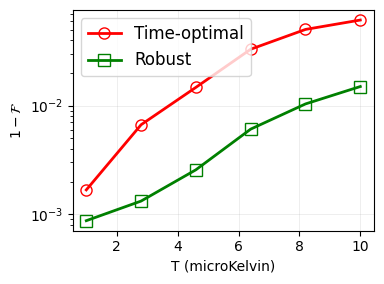

In [13]:
Tlist=np.linspace(1e-6,1e-5,6)
fig, ax = plt.subplots(figsize=(4, 3))
plt.rcParams.update({'font.size': 12})
plt.rcParams['lines.linewidth'] = 2
# Plot the first series

ax.plot(Tlist*1e6, FTOTdep480D, label='Time-optimal', color='red', marker='o', mfc='none', markersize=8)
# Plot the third series
ax.plot(Tlist*1e6, RobustTdep480D, label='Robust', color='green', marker='s', mfc='none', markersize=8)


# Add labels, title, and a legend for clarity
ax.set_xlabel("T (microKelvin)")
ax.set_ylabel(r"$1-\mathcal{F}$")
ax.set_yscale('log')
ax.legend() # Displays the labels defined in the scatter calls
fig.tight_layout()
ax.grid(alpha=0.3)
plt.savefig('RobustnessMonteCarlo480Dlifetimes.svg', format='svg')
# Display the plot
plt.show()

***Amplitude-robust for smaller detuning 5 GHz  <span style="color:red">Влад</span>***

In [18]:
w0=1e-6 #beam waist in meters
lam=850e-9 #trap wavelength
z0=np.pi*(w0**2)/lam
cl= 299792458 #light velocity m/s
kB=1.380649e-23 #Boltzmann constant
MRb=87*1.660539e-27 #Rb 87 mass  
U0=1e-4 #trap potential
C6=-2058e3 #c6 coefficient for 76s in MHz
wr=np.sqrt(4*kB*U0/(MRb*w0**2)) #radial trap frequency in kHz
wz=np.sqrt(2*kB*U0/(MRb*z0**2)) #axial trap frequency in kHz
pulse_ansatz_to = ro.pulses.PulseAnsatz(detuning_ansatz=ro.pulses.const,
                                        phase_ansatz=ro.pulses.lin_sin_cos_crab,
                                        rabi_ansatz=ro.pulses.softbox_seventh_order_smoothstep)
lifetimep=26e-3
lifetimeRyd=180.43861733582934 #76S lifetime
initial_params=(1.0, [9.121445655822754], [0.40243253111839294, 0.7589524984359741, -1.2777073383331299, 0.2604377269744873, 1.7878552675247192, 0.1500038355588913, -0.13677142560482025, 0.14020198583602905, -0.1863752007484436, -0.14489804208278656, 0.1924409419298172, -0.018599489703774452, -0.6102868318557739, 0.8758513927459717, 0.1380738765001297, -0.32945048809051514, -0.5795151591300964, -0.1269419640302658, 0.5316967964172363, -0.2201061248779297, -0.6058393120765686], [22.428089141845703, 0.24895963072776794])
Time_Scaling=5 #Scaling factor used in Rabi frequencies, decay rates and interaction strengths.
Tlist=np.linspace(1e-6,1e-5,6)
rng = np.random.default_rng()

RobustTdep480Ds=[]
N = 100 #data size

for j in range(len(Tlist)):
    T=Tlist[j] #list of temperatures
    sigma_xy=np.sqrt(kB*T/(MRb*wr**2))  #x and y spread
    sigma_z=np.sqrt(kB*T/(MRb*wz**2)) #z spread
    sigma_v=np.sqrt(kB*T/(MRb)) # velocity spread
    
    
    t = rng.uniform(0, 2*np.pi/omega_z, size=(N, 2))  #time points during one cycle of trap motion
    # Initial conditions for two atoms (2) for N shots
    x0  = rng.normal(0.0, sigma_xy, size=(N, 2))
    y0  = rng.normal(0.0, sigma_xy, size=(N, 2))
    z0  = rng.normal(0.0, sigma_z,  size=(N, 2))
    vx0 = rng.normal(0.0, sigma_v,  size=(N, 2))
    vy0 = rng.normal(0.0, sigma_v,  size=(N, 2))
    vz0 = rng.normal(0.0, sigma_v,  size=(N, 2))

    # Harmonic evolution (analytic)
    cr, sr = np.cos(wr * t), np.sin(wr * t)
    cz, sz = np.cos(wz * t), np.sin(wz * t)

    x  = x0 * cr + (vx0 / wr) * sr
    y  = y0 * cr + (vy0 / wr) * sr
    z  = z0 * cz + (vz0 / wz) * sz
    vz = -z0 *wz * sz + vz0 * cz
    R=np.sqrt((x[:,0]-x[:,1]+4.1e-6)**2+(y[:,0]-y[:,1])**2+(z[:,0]-z[:,1])**2)*1e6
    Varr=-2*np.pi*C6/R**6
    r = np.sqrt(x*x + y*y)
    
    Radial1 = r[:, 0]
    Axial1 = z[:, 0]
    Radial2 = r[:, 1]
    Axial2 = z[:, 1]
    Vz1= vz[:, 0]
    Vz2= vz[:, 1]
    Doppler1=Vz1*1e-6*2*np.pi*(1/(480e-9)-1/(780e-9))/Time_Scaling 
    Doppler2=Vz2*1e-6*2*np.pi*(1/(480e-9)-1/(780e-9))/Time_Scaling
    
    ScalingP1=Rabi(Radial1,Axial1,780e-9)
    ScalingS1=Rabi(Radial1,Axial1,480e-9)
    ScalingP2=Rabi(Radial2,Axial2,780e-9)
    ScalingS2=Rabi(Radial2,Axial2,480e-9)

    Detuning1=(initial_params[1]+Doppler1)/initial_params[1]
    Detuning2=(initial_params[1]+Doppler2)/initial_params[1]
    FRobustT=[]
    print("j= %.i " % j)
    for i in range(len(ScalingP1)):
        gate = CZGateTwoPhotonAsymm(Vnn=Varr[i]/Time_Scaling,Delta1P=2*np.pi*5000/Time_Scaling,Delta2P=2*np.pi*5000/Time_Scaling,DecayP=1/Time_Scaling/lifetimep,DecayR=1/Time_Scaling/lifetimeRyd,s1=ScalingS1[i] ,s2=ScalingS2[i],p1=ScalingP1[i] ,p2=ScalingP2[i],f1= Detuning1[i],f2= Detuning2[i])
        pulse_params  = initial_params[0],initial_params[1],initial_params[2],initial_params[3],
        time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz_to, pulse_params)
        errF=1-gate.process_fidelity(time_evolved_basis_states).item()
        FRobustT.append(errF)
        print(i,errF)
    RobustTdep480Ds.append(np.mean(FRobustT).item())
RobustTdep480Ds

j= 0 
0 0.007097737194192266
1 0.006985741101459997
2 0.006967133417415061
3 0.007051045360442321
4 0.007280531959023229
5 0.006961839595756136
6 0.007447412216388449
7 0.007207877283562092
8 0.006960002740990068
9 0.007121412158738405
10 0.006948170861591274
11 0.007141609024791884
12 0.0069972114751071235
13 0.00744786055246438
14 0.007009818477566099
15 0.007222648486580163
16 0.0069751345524416974
17 0.006973393220390478
18 0.007124507615021813
19 0.006925898719116197
20 0.00709943173217642
21 0.00706372541224598
22 0.007073253555947123
23 0.007042827762740345
24 0.006989045759430712
25 0.0070025349059380515
26 0.006940296376764188
27 0.007045238754503025
28 0.006996629754939532
29 0.007176451061245204
30 0.006994233049386955
31 0.00720437257236306
32 0.00691460847713854
33 0.007269234236048527
34 0.0069830084562821915
35 0.00700780657342448
36 0.0071169918455832315
37 0.007043138621301903
38 0.006955426812192189
39 0.0070259690727646484
40 0.0069587258930982054
41 0.00703561757713

[0.007051503465430626,
 0.007257829631479177,
 0.010010618427673918,
 0.011050926636997211,
 0.013813543784025889,
 0.024095168067171997]

In [8]:
RobustTdep480Ds=[0.007472192590997051,
 0.007478268569075116,
 0.008426696507988168,
 0.010723715094516634,
 0.015888593551809164,
 0.018208115119289273]

***Time optimal for smaller detuning 5 GHz  <span style="color:red">Влад</span>***

In [19]:
w0=1e-6 #beam waist in meters
lam=850e-9 #trap wavelength
z0=np.pi*(w0**2)/lam
cl= 299792458 #light velocity m/s
kB=1.380649e-23 #Boltzmann constant
MRb=87*1.660539e-27 #Rb 87 mass  
U0=1e-4 #trap potential
C6=-2058e3 #c6 coefficient for 76s in MHz
wr=np.sqrt(4*kB*U0/(MRb*w0**2)) #radial trap frequency in kHz
wz=np.sqrt(2*kB*U0/(MRb*z0**2)) #axial trap frequency in kHz
Time_Scaling=10 #Scaling factor used in Rabi frequencies, decay rates and interaction strengths.

pulse_ansatz_to = ro.pulses.PulseAnsatz(detuning_ansatz=ro.pulses.const,
                                        phase_ansatz=ro.pulses.sin_crab,
                                        rabi_ansatz=ro.pulses.softbox_seventh_order_smoothstep)
lifetimep=26e-3
lifetimeRyd=180.43861733582934 #76S lifetime
initial_params=(1.0, [0.15980202], [1.26093899, 0.66637697], [8.21939241, 0.14456943])

Tlist=np.linspace(1e-6,1e-5,6)
rng = np.random.default_rng()
FTOTdep480Ds=[]
N = 100 #data size

for j in range(len(Tlist)):
    T=Tlist[j] #list of temperatures
    sigma_xy=np.sqrt(kB*T/(MRb*wr**2))  #x and y spread
    sigma_z=np.sqrt(kB*T/(MRb*wz**2)) #z spread
    sigma_v=np.sqrt(kB*T/(MRb)) # velocity spread
    
    
    t = rng.uniform(0, 2*np.pi/omega_z, size=(N, 2))  #time points during one cycle of trap motion
    # Initial conditions for two atoms (2) for N shots
    x0  = rng.normal(0.0, sigma_xy, size=(N, 2))
    y0  = rng.normal(0.0, sigma_xy, size=(N, 2))
    z0  = rng.normal(0.0, sigma_z,  size=(N, 2))
    vx0 = rng.normal(0.0, sigma_v,  size=(N, 2))
    vy0 = rng.normal(0.0, sigma_v,  size=(N, 2))
    vz0 = rng.normal(0.0, sigma_v,  size=(N, 2))

    # Harmonic evolution (analytic)
    cr, sr = np.cos(wr * t), np.sin(wr * t)
    cz, sz = np.cos(wz * t), np.sin(wz * t)

    x  = x0 * cr + (vx0 / wr) * sr
    y  = y0 * cr + (vy0 / wr) * sr
    z  = z0 * cz + (vz0 / wz) * sz
    vz = -z0 *wz * sz + vz0 * cz
    R=np.sqrt((x[:,0]-x[:,1]+4e-6)**2+(y[:,0]-y[:,1])**2+(z[:,0]-z[:,1])**2)*1e6
    Varr=-2*np.pi*C6/R**6
    r = np.sqrt(x*x + y*y)
    
    Radial1 = r[:, 0]
    Axial1 = z[:, 0]
    Radial2 = r[:, 1]
    Axial2 = z[:, 1]
    Vz1= vz[:, 0]
    Vz2= vz[:, 1]
    Doppler1=Vz1*1e-6*2*np.pi*(1/(480e-9)-1/(780e-9))/Time_Scaling 
    Doppler2=Vz2*1e-6*2*np.pi*(1/(480e-9)-1/(780e-9))/Time_Scaling 
    
    ScalingP1=Rabi(Radial1,Axial1,780e-9)
    ScalingS1=Rabi(Radial1,Axial1,480e-9)
    ScalingP2=Rabi(Radial2,Axial2,780e-9)
    ScalingS2=Rabi(Radial2,Axial2,480e-9)

    Detuning1=(initial_params[1]+Doppler1)/initial_params[1]
    Detuning2=(initial_params[1]+Doppler2)/initial_params[1]
    FRobustT=[]
    print("j= %.i " % j)
    for i in range(len(ScalingP1)):
        gate = CZGateTwoPhotonAsymm(Vnn=Varr[i]/Time_Scaling,Delta1P=2*np.pi*5000/Time_Scaling,Delta2P=2*np.pi*5000/Time_Scaling,DecayP=1/Time_Scaling/lifetimep,DecayR=1/Time_Scaling/lifetimeRyd,s1=ScalingS1[i] ,s2=ScalingS2[i],p1=ScalingP1[i] ,p2=ScalingP2[i],f1= Detuning1[i],f2= Detuning2[i])
        pulse_params  = initial_params[0],initial_params[1],initial_params[2],initial_params[3],
        time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz_to, pulse_params)
        errF=1-gate.process_fidelity(time_evolved_basis_states).item()
        FRobustT.append(errF)
        print(i,errF)
    FTOTdep480Ds.append(np.mean(FRobustT).item())
FTOTdep480Ds

j= 0 
0 0.007247240783171627
1 0.007315327632543722
2 0.00712270740006038
3 0.00742735064072042
4 0.0073856966677372515
5 0.007190454494688581
6 0.007095649452655173
7 0.007324140903461007
8 0.008084919012052993
9 0.007883899487782675
10 0.007229433767979687
11 0.007823391568882121
12 0.007321884304050674
13 0.007749692611680348
14 0.012003253393153779
15 0.007185112416459027
16 0.007337763109779516
17 0.007191600409967913
18 0.00722437166006662
19 0.007126033175427482
20 0.0073216177013493144
21 0.007302551699366
22 0.010296492358724318
23 0.007628504116411028
24 0.007111047490324984
25 0.0071276770877728435
26 0.007420484453315113
27 0.007181214732967067
28 0.009463568150239299
29 0.007283279640911577
30 0.009635330404072606
31 0.007727381864917393
32 0.007387856987938202
33 0.008132790184247063
34 0.007980523493185232
35 0.0071407836009954595
36 0.0074150220139043155
37 0.007317005166271651
38 0.007797984811832026
39 0.007247440116066373
40 0.00717570043209137
41 0.00716347400969530

[0.007569907617940862,
 0.014215399626384484,
 0.02352012766924667,
 0.03303215391328354,
 0.06170183199234074,
 0.06897872737165289]

In [14]:
FTOTdep480Ds=[0.007840216369733331,
 0.013306592977888413,
 0.02700025019281419,
 0.036693025696596056,
 0.06314915298560618,
 0.07355757536541398]

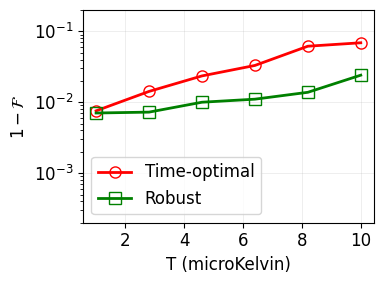

In [21]:
Tlist=np.linspace(1e-6,1e-5,6)
fig, ax = plt.subplots(figsize=(4, 3))
plt.rcParams.update({'font.size': 12})
plt.rcParams['lines.linewidth'] = 2
# Plot the first series

ax.plot(Tlist*1e6, FTOTdep480Ds, label='Time-optimal', color='red', marker='o', mfc='none', markersize=8)
# Plot the third series
ax.plot(Tlist*1e6, RobustTdep480Ds, label='Robust', color='green', marker='s', mfc='none', markersize=8)


# Add labels, title, and a legend for clarity
ax.set_xlabel("T (microKelvin)")
ax.set_ylabel(r"$1-\mathcal{F}$")
ax.set_yscale('log')
ax.set_ylim(2e-4, 2e-1)
ax.legend() # Displays the labels defined in the scatter calls
fig.tight_layout()
ax.grid(alpha=0.3)
plt.savefig('RobustnessMonteCarlo480Dlifetimes5GHz.svg', format='svg')
# Display the plot
plt.show()

**Monte-Carlo simulation for two-photon Rydberg excitation at 420 nm and 1013 nm with Doppler**

 ***Amplitude-robust 420 nm+1013 nm 76S state 100 ns gate duration with 70 GHz detuning 4 microns interatomic distance. The gate timing is rescaled by a factor of 10 <span style="color:red">Посчитано</span>***

In [15]:
w0=1e-6 #beam waist in meters
lam=850e-9 #trap wavelength
z0=np.pi*(w0**2)/lam
cl= 299792458 #light velocity m/s
kB=1.380649e-23 #Boltzmann constant
MRb=87*1.660539e-27 #Rb 87 mass  
U0=1e-4 #trap potential
C6=-2058e3 #c6 coefficient for 76s in MHz
wr=np.sqrt(4*kB*U0/(MRb*w0**2)) #radial trap frequency in kHz
wz=np.sqrt(2*kB*U0/(MRb*z0**2)) #axial trap frequency in kHz
pulse_ansatz_to = ro.pulses.PulseAnsatz(detuning_ansatz=ro.pulses.const,
                                        phase_ansatz=ro.pulses.lin_sin_cos_crab,
                                        rabi_ansatz=ro.pulses.softbox_seventh_order_smoothstep)
lifetimep=26e-3
lifetimeRyd=180.43861733582934 #76S lifetime
initial_params=(1.0, [9.121445655822754], [0.40243253111839294, 0.7589524984359741, -1.2777073383331299, 0.2604377269744873, 1.7878552675247192, 0.1500038355588913, -0.13677142560482025, 0.14020198583602905, -0.1863752007484436, -0.14489804208278656, 0.1924409419298172, -0.018599489703774452, -0.6102868318557739, 0.8758513927459717, 0.1380738765001297, -0.32945048809051514, -0.5795151591300964, -0.1269419640302658, 0.5316967964172363, -0.2201061248779297, -0.6058393120765686], [22.428089141845703, 0.24895963072776794])
Time_Scaling=5 #Scaling factor used in Rabi frequencies, decay rates and interaction strengths.
Tlist=np.linspace(1e-6,1e-5,6)
rng = np.random.default_rng()

RobustTdep420D=[]
N = 100 #data size

for j in range(len(Tlist)):
    T=Tlist[j] #list of temperatures
    sigma_xy=np.sqrt(kB*T/(MRb*wr**2))  #x and y spread
    sigma_z=np.sqrt(kB*T/(MRb*wz**2)) #z spread
    sigma_v=np.sqrt(kB*T/(MRb)) # velocity spread
    
    
    t = rng.uniform(0, 2*np.pi/omega_z, size=(N, 2))  #time points during one cycle of trap motion
    # Initial conditions for two atoms (2) for N shots
    x0  = rng.normal(0.0, sigma_xy, size=(N, 2))
    y0  = rng.normal(0.0, sigma_xy, size=(N, 2))
    z0  = rng.normal(0.0, sigma_z,  size=(N, 2))
    vx0 = rng.normal(0.0, sigma_v,  size=(N, 2))
    vy0 = rng.normal(0.0, sigma_v,  size=(N, 2))
    vz0 = rng.normal(0.0, sigma_v,  size=(N, 2))

    # Harmonic evolution (analytic)
    cr, sr = np.cos(wr * t), np.sin(wr * t)
    cz, sz = np.cos(wz * t), np.sin(wz * t)

    x  = x0 * cr + (vx0 / wr) * sr
    y  = y0 * cr + (vy0 / wr) * sr
    z  = z0 * cz + (vz0 / wz) * sz
    vz = -z0 *wz * sz + vz0 * cz
    R=np.sqrt((x[:,0]-x[:,1]+4.1e-6)**2+(y[:,0]-y[:,1])**2+(z[:,0]-z[:,1])**2)*1e6
    Varr=-2*np.pi*C6/R**6
    r = np.sqrt(x*x + y*y)
    
    Radial1 = r[:, 0]
    Axial1 = z[:, 0]
    Radial2 = r[:, 1]
    Axial2 = z[:, 1]
    Vz1= vz[:, 0]
    Vz2= vz[:, 1]
    Doppler1=Vz1*1e-6*2*np.pi*(1/(420e-9)-1/(1013e-9))/Time_Scaling 
    Doppler2=Vz2*1e-6*2*np.pi*(1/(420e-9)-1/(1013e-9))/Time_Scaling
    
    ScalingP1=Rabi(Radial1,Axial1,1013e-9)
    ScalingS1=Rabi(Radial1,Axial1,420e-9)
    ScalingP2=Rabi(Radial2,Axial2,1013e-9)
    ScalingS2=Rabi(Radial2,Axial2,420e-9)

    Detuning1=(initial_params[1]+Doppler1)/initial_params[1]
    Detuning2=(initial_params[1]+Doppler2)/initial_params[1]
    FRobustT=[]
    print("j= %.i " % j)
    for i in range(len(ScalingP1)):
        gate = CZGateTwoPhotonAsymm(Vnn=Varr[i]/Time_Scaling,Delta1P=2*np.pi*70000/Time_Scaling,Delta2P=2*np.pi*70000/Time_Scaling,DecayP=1/Time_Scaling/lifetimep,DecayR=1/Time_Scaling/lifetimeRyd,s1=ScalingS1[i] ,s2=ScalingS2[i],p1=ScalingP1[i] ,p2=ScalingP2[i],f1= Detuning1[i],f2= Detuning2[i])
        pulse_params  = initial_params[0],initial_params[1],initial_params[2],initial_params[3],
        time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz_to, pulse_params)
        errF=1-gate.process_fidelity(time_evolved_basis_states).item()
        FRobustT.append(errF)
        print(i,errF)
    RobustTdep420D.append(np.mean(FRobustT).item())
RobustTdep420D

j= 0 
0 0.0009216900115117665
1 0.0007974882882271217
2 0.0008004689484534255
3 0.0010906990753548618
4 0.0008678841404269333
5 0.0011296768360450349
6 0.00078784652605568
7 0.000799334884312386
8 0.0008017789569482181
9 0.0013051394847205522
j= 1 
0 0.0016758398284458798
1 0.0018946051088332139
2 0.010256098285571502
3 0.0022334830017840535
4 0.0025032170060698133
5 0.002569287244464369
6 0.003217661696472751
7 0.0012912237591085063
8 0.000977758234822157
9 0.0017033354178341842
j= 2 
0 0.0009388538081324116
1 0.0011357198146155767
2 0.0043760092277519425
3 0.004259889982183296
4 0.004177837092920078
5 0.0011503257218449248
6 0.0015332812412520713
7 0.0014969101767350335
8 0.0012607746303168188
9 0.001488488267279764
j= 3 
0 0.048023716258978166
1 0.0038479244629266995
2 0.0030399704256797166
3 0.013363403449770939
4 0.005583884401799133
5 0.04887206532062116
6 0.004807464444277265
7 0.004834440537365481
8 0.009131851653559231
9 0.010369508780389336
j= 4 
0 0.002391611168794938
1 0.00

[0.000930200715205598,
 0.002832250958340643,
 0.0021818089963031918,
 0.015187422973536712,
 0.028797271164780213,
 0.105885494606906]

In [16]:
RobustTdep420D=[0.0011548973909577976,
 0.0027625261021637414,
 0.007993786871972226,
 0.013535326672220443,
 0.022840322142049153,
 0.04033725546604635]

***Smooth time optimal 420 nm+1013 nm <span style="color:red">Влад</span>***

In [14]:
w0=1e-6 #beam waist in meters
lam=850e-9 #trap wavelength
z0=np.pi*(w0**2)/lam
cl= 299792458 #light velocity m/s
kB=1.380649e-23 #Boltzmann constant
MRb=87*1.660539e-27 #Rb 87 mass  
U0=1e-4 #trap potential
C6=-2058e3 #c6 coefficient for 76s in MHz
wr=np.sqrt(4*kB*U0/(MRb*w0**2)) #radial trap frequency in kHz
wz=np.sqrt(2*kB*U0/(MRb*z0**2)) #axial trap frequency in kHz
Time_Scaling=10 #Scaling factor used in Rabi frequencies, decay rates and interaction strengths.

pulse_ansatz_to = ro.pulses.PulseAnsatz(detuning_ansatz=ro.pulses.const,
                                        phase_ansatz=ro.pulses.sin_crab,
                                        rabi_ansatz=ro.pulses.softbox_seventh_order_smoothstep)
lifetimep=26e-3
lifetimeRyd=180.43861733582934 #76S lifetime
initial_params=(1.0, [0.15980202], [1.26093899, 0.66637697], [8.21939241, 0.14456943])

Tlist=np.linspace(1e-6,1e-5,6)
rng = np.random.default_rng()
FTOTdep420D=[]
N = 100 #data size

for j in range(len(Tlist)):
    T=Tlist[j] #list of temperatures
    sigma_xy=np.sqrt(kB*T/(MRb*wr**2))  #x and y spread
    sigma_z=np.sqrt(kB*T/(MRb*wz**2)) #z spread
    sigma_v=np.sqrt(kB*T/(MRb)) # velocity spread
    
    
    t = rng.uniform(0, 2*np.pi/omega_z, size=(N, 2))  #time points during one cycle of trap motion
    # Initial conditions for two atoms (2) for N shots
    x0  = rng.normal(0.0, sigma_xy, size=(N, 2))
    y0  = rng.normal(0.0, sigma_xy, size=(N, 2))
    z0  = rng.normal(0.0, sigma_z,  size=(N, 2))
    vx0 = rng.normal(0.0, sigma_v,  size=(N, 2))
    vy0 = rng.normal(0.0, sigma_v,  size=(N, 2))
    vz0 = rng.normal(0.0, sigma_v,  size=(N, 2))

    # Harmonic evolution (analytic)
    cr, sr = np.cos(wr * t), np.sin(wr * t)
    cz, sz = np.cos(wz * t), np.sin(wz * t)

    x  = x0 * cr + (vx0 / wr) * sr
    y  = y0 * cr + (vy0 / wr) * sr
    z  = z0 * cz + (vz0 / wz) * sz
    vz = -z0 *wz * sz + vz0 * cz
    R=np.sqrt((x[:,0]-x[:,1]+4e-6)**2+(y[:,0]-y[:,1])**2+(z[:,0]-z[:,1])**2)*1e6
    Varr=-2*np.pi*C6/R**6
    r = np.sqrt(x*x + y*y)
    
    Radial1 = r[:, 0]
    Axial1 = z[:, 0]
    Radial2 = r[:, 1]
    Axial2 = z[:, 1]
    Vz1= vz[:, 0]
    Vz2= vz[:, 1]
    Doppler1=Vz1*1e-6*2*np.pi*(1/(420e-9)-1/(1013e-9))/Time_Scaling 
    Doppler2=Vz2*1e-6*2*np.pi*(1/(420e-9)-1/(1013e-9))/Time_Scaling 
    
    ScalingP1=Rabi(Radial1,Axial1,1013e-9)
    ScalingS1=Rabi(Radial1,Axial1,420e-9)
    ScalingP2=Rabi(Radial2,Axial2,1013e-9)
    ScalingS2=Rabi(Radial2,Axial2,420e-9)

    Detuning1=(initial_params[1]+Doppler1)/initial_params[1]
    Detuning2=(initial_params[1]+Doppler2)/initial_params[1]
    FRobustT=[]
    print("j= %.i " % j)
    for i in range(len(ScalingP1)):
        gate = CZGateTwoPhotonAsymm(Vnn=Varr[i]/Time_Scaling,Delta1P=2*np.pi*70000/Time_Scaling,Delta2P=2*np.pi*70000/Time_Scaling,DecayP=1/Time_Scaling/lifetimep,DecayR=1/Time_Scaling/lifetimeRyd,s1=ScalingS1[i] ,s2=ScalingS2[i],p1=ScalingP1[i] ,p2=ScalingP2[i],f1= Detuning1[i],f2= Detuning2[i])
        pulse_params  = initial_params[0],initial_params[1],initial_params[2],initial_params[3],
        time_evolved_basis_states = ro.simulation.evolve(gate, pulse_ansatz_to, pulse_params)
        errF=1-gate.process_fidelity(time_evolved_basis_states).item()
        FRobustT.append(errF)
        print(i,errF)
    FTOTdep420D.append(np.mean(FRobustT).item())
FTOTdep420D

j= 0 
0 0.0011753281341470023
1 0.0024421491326529488
2 0.0021137642781274835
3 0.00267121896005329
4 0.0016265625422980934
5 0.0016601911837107464
6 0.0014798687010714184
7 0.001262658048019838
8 0.0008336851999787287
9 0.0018129933434772871
10 0.0012680516947208842
11 0.001411820698065669
12 0.001406448536130367
13 0.0009169781774243102
14 0.0011716862384303361
15 0.002415124268148938
16 0.0007777650564824157
17 0.0008311868114481147
18 0.0011095582113360702
19 0.0012490812169126952
20 0.0010692319716499865
21 0.0009455257661270533
22 0.0011762173890256244
23 0.0010601800654820304
24 0.002494174602764909
25 0.0015966998138070565
26 0.0011690420011761793
27 0.0008697392353801403
28 0.0037021603859304086
29 0.001028890075636002
30 0.0031415838858320777
31 0.0008399710642198466
32 0.0013583545739375147
33 0.001098817532541374
34 0.0021554683497498894
35 0.004421739546938808
36 0.0019103599057859189
37 0.0013135852423886707
38 0.0020308016533524542
39 0.0017047670871146448
40 0.003474806

[0.0018957985591426618,
 0.008590485524502724,
 0.020687435293963025,
 0.03396902302227564,
 0.05494812819118119,
 0.08205729677580884]

In [8]:
FTOTdep420D=[0.0018957985591426618,
 0.008590485524502724,
 0.020687435293963025,
 0.03396902302227564,
 0.05494812819118119,
 0.08205729677580884]

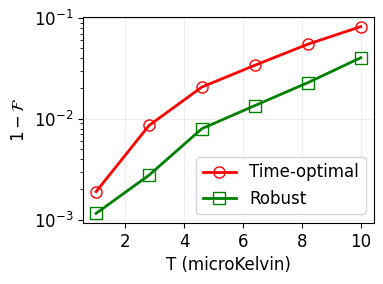

In [17]:
Tlist=np.linspace(1e-6,1e-5,6)
fig, ax = plt.subplots(figsize=(4, 3))
plt.rcParams.update({'font.size': 12})
plt.rcParams['lines.linewidth'] = 2
# Plot the first series

ax.plot(Tlist*1e6, FTOTdep420D, label='Time-optimal', color='red', marker='o', mfc='none', markersize=8)
# Plot the third series
ax.plot(Tlist*1e6, RobustTdep420D, label='Robust', color='green', marker='s', mfc='none', markersize=8)


# Add labels, title, and a legend for clarity
ax.set_xlabel("T (microKelvin)")
ax.set_ylabel(r"$1-\mathcal{F}$")
ax.set_yscale('log')
ax.legend() # Displays the labels defined in the scatter calls
fig.tight_layout()
ax.grid(alpha=0.3)
plt.savefig('RobustnessMonteCarlo420Dlifetimes.svg', format='svg')
# Display the plot
plt.show()